# H640W1088的加速测试

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
from ultralytics import YOLO
import torch
import torch.nn as nn
from loguru import logger
import os
import tensorrt as trt
import onnxruntime
import pytorch_quantization.nn as quant_nn
from pytorch_quantization.nn import TensorQuantizer  # 来自你QAT框架（如 MQBench 等）
import onnx
from onnxsim import simplify
try:
    import onnxsim
except ImportError:
    onnxsim = None
print("ONNX Runtime版本:", onnxruntime.__version__)
print("可用设备:", onnxruntime.get_device())
print("支持Provider:", onnxruntime.get_available_providers())
print(f'trt version:{trt.__version__}')
print(f'torch cuda available:{torch.cuda.is_available()}')

ONNX Runtime版本: 1.22.0
可用设备: GPU
支持Provider: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
trt version:8.6.1
torch cuda available:True


In [2]:
data_yaml_file = './datasets/my-coco-pose.yaml' # 测试数据
device = 'cuda:0'

In [3]:
def load_model(org_model_path, pt_model_path, device='cuda:0'):
    model = YOLO(org_model_path)
    model1 = torch.load(pt_model_path, map_location=device)["model"]
    model1.float()
    model1.eval()
    with torch.no_grad():
        model1.fuse()
    model.model = model1
    model.args = vars(model.args)
    model.model.args = model.args
    model.model.task = model.task
    return model
def print_model_size(pt_path):
    if os.path.exists(pt_path):
        size_bytes = os.path.getsize(pt_path)
        size_mb = size_bytes / (1024 * 1024)
        print(f"📦 模型文件大小: {size_bytes} 字节 ({size_mb:.2f} MB)")
    else:
        print("❌ 找不到该 .pt 文件，请检查路径是否正确")

In [3]:
org_pt_path = './weights/yolov8s-pose.pt'
print_model_size(org_pt_path)

📦 模型文件大小: 23513657 字节 (22.42 MB)


In [4]:
dense_model = YOLO(org_pt_path, task='pose')
dense_model.info()

YOLOv8s-pose summary: 144 layers, 11,626,046 parameters, 0 gradients, 30.4 GFLOPs


(144, 11626046, 0, 30.406830400000004)

# fp16-->TRT engine

## 导出onnx

In [2]:
import torch
from ultralytics import YOLO

def export_yolov8_pose_onnx(
    model_path="yolov8s-pose.pt",
    onnx_path="yolov8s-pose-dynamic.onnx",
    img_height=640,
    img_width=1088,
    dynamic_batch=True,
    max_batch_size=16,
    opset_version=13,
    sim=False
):
    # 加载模型
    model = YOLO(model_path, task='pose')
    model.eval()

    # 动态或静态 batch
    if dynamic_batch:
        dummy_input = torch.randn(1, 3, img_height, img_width)  # 用于trace
        dynamic_axes = {
            "images": {0: "batch"},
            "output0": {0: "batch"}
        }
    else:
        dummy_input = torch.randn(1, 3, img_height, img_width)
        dynamic_axes = None

    # 设置导出参数
    torch.onnx.export(
        model.model,                         # 注意：ultralytics.YOLO的内部模型
        dummy_input,
        onnx_path,
        input_names=["images"],
        output_names=["output0"],
        export_params=True,
        opset_version=opset_version,
        do_constant_folding=True,
        dynamic_axes=dynamic_axes
    )
    print(f"ONNX 导出完成: {onnx_path}")
    if sim:
        onnx_model = onnx.load(onnx_path)
        onnx.checker.check_model(onnx_model) 
        try:
            onnx_model, check = onnxsim.simplify(onnx_model)
            assert check, 'assert check failed'
        except Exception as e:
            print(f'Simplifier failure: {e}')
        onnx.save(onnx_model, onnx_path)
        print(f'ONNX simplify export success, saved as {onnx_path}')


if __name__ == "__main__":
    export_yolov8_pose_onnx(
        model_path="weights/yolov8s-pose-prune-sp0.4.pt",
        onnx_path="weights/yolov8s-pose-prune-sp0.4-op13-h640w1088-dynamic.onnx",
        img_height=640,
        img_width=1088,
        dynamic_batch=True,
        max_batch_size=16,
        opset_version=13,
        sim=False
    )

/data/xl/Projects/EdgeLite/ultralytics/nn/modules/head.py:163: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if self.format != "imx" and (self.dynamic or self.shape != shape):
/data/xl/Projects/EdgeLite/ultralytics/utils/tal.py:372: TracerWarning: Iterating over a tensor might cause the trace to be incorrect. Passing a tensor of different shape won't change the number of iterations executed (and might lead to errors or silently give incorrect results).
  for i, stride in enumerate(strides):


ONNX 导出完成: weights/yolov8s-pose-prune-sp0.4-op13-h640w1088-dynamic.onnx


## 验证onnx

In [4]:
import torch
import numpy as np
import onnx
import onnxruntime as ort
from ultralytics import YOLO

def verify_onnx(onnx_path, model_path="weights/yolov8s-pose.pt", batch=10, img_size=(640,1088)):
    # 加载 YOLOv8 原始模型
    model = YOLO(model_path)
    model.eval()

    # 随机生成测试输入
    x = torch.randn(batch, 3, img_size[0], img_size[1])

    # PyTorch 推理
    with torch.no_grad():
        torch_out = model.model(x)
        if isinstance(torch_out, (list, tuple)):
            torch_out = torch_out[0]
        print(f"torch out shape-->{torch_out.shape}")
        torch_out = torch_out.detach().cpu().numpy()

    # 检查 ONNX 文件是否合法
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    print(f"ONNX 文件结构合法: {onnx_path}")

    # ONNX Runtime 推理
    session = ort.InferenceSession(
        onnx_path,
        providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    )
    inputs = {session.get_inputs()[0].name: x.cpu().numpy()}
    onnx_out = session.run(None, inputs)[0]
    print(f"onnx out shape-->{onnx_out.shape}")

    # 比较输出误差
    mae = np.mean(np.abs(torch_out - onnx_out))
    max_err = np.max(np.abs(torch_out - onnx_out))
    print(f"平均绝对误差 MAE: {mae:.6f}")
    print(f"最大绝对误差 MaxErr: {max_err:.6f}")

    # 验证精度
    if mae < 1e-4:
        print("✅ ONNX 推理正确，和 PyTorch 输出一致")
    else:
        print("⚠️ 警告: ONNX 和 PyTorch 输出存在偏差，可能是导出问题")

if __name__ == "__main__":
    verify_onnx(
        onnx_path="weights/yolov8s-pose-prune-sp0.4-op13-h640w1088-dynamic.onnx",
        model_path="weights/yolov8s-pose-prune-sp0.4.pt",
        batch=10,
        img_size=(640,1088)
    )

torch out shape-->torch.Size([10, 56, 14280])
ONNX 文件结构合法: weights/yolov8s-pose-prune-sp0.4-op13-h640w1088-dynamic.onnx
onnx out shape-->(10, 56, 14280)
平均绝对误差 MAE: 0.011246
最大绝对误差 MaxErr: 1.421875
⚠️ 警告: ONNX 和 PyTorch 输出存在偏差，可能是导出问题


In [51]:
verify_onnx(
    onnx_path="weights/yolov8s-pose-op13-h640w1088-dynamic-sim.onnx",
    model_path="weights/yolov8s-pose.pt",
    batch=10,
    img_size=(640,1088)
)

torch out shape-->torch.Size([10, 56, 14280])
ONNX 文件结构合法: weights/yolov8s-pose-op13-h640w1088-dynamic-sim.onnx
onnx out shape-->(10, 56, 14280)
平均绝对误差 MAE: 0.007799
最大绝对误差 MaxErr: 0.623535
⚠️ 警告: ONNX 和 PyTorch 输出存在偏差，可能是导出问题


In [45]:
    verify_onnx(
        onnx_path="weights/yolov8s-pose-op16-h640w1088-dynamic.onnx",
        model_path="weights/yolov8s-pose.pt",
        batch=10,
        img_size=(640,1088)
    )

torch out shape-->torch.Size([10, 56, 14280])
ONNX 文件结构合法: weights/yolov8s-pose-op16-h640w1088-dynamic.onnx
onnx out shape-->(10, 56, 14280)
平均绝对误差 MAE: 0.007816
最大绝对误差 MaxErr: 0.694824
⚠️ 警告: ONNX 和 PyTorch 输出存在偏差，可能是导出问题


2025-08-26 11:10:14.800125301 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.
2025-08-26 11:10:14.800150108 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.
2025-08-26 11:10:14.800160976 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.


opset13似乎是比较准确的

* 14280 → 输入 640x1088 时，YOLOv8-Pose 检测头在三个尺度上输出的预测总数
> 3个检测头的stride分别为8, 16, 32
>> 第一个检测头预测数量：(640/8) * (1088/8) = 80 * 136 = 10880
>> 第二个检测头预测数量：(640/16) * (1088/16) = 40 * 68 = 2720
>> 第三个检测头预测数量：(640/32) * (1088/32) = 20 * 34 = 680

总共预测数量: 10880 + 2720 + 680 = 14280

In [47]:
import torch
import onnx
import onnxruntime as ort
import numpy as np
from ultralytics import YOLO

# -----------------------------
# 1. 加载 PyTorch 模型
# -----------------------------
model_path = "weights/yolov8s-pose.pt"
onnx_path = "weights/yolov8s-pose-op13-h640w1088-dynamic.onnx"
model = YOLO(model_path)

# -----------------------------
# 2. 加载测试图片
# -----------------------------
img = torch.randn(1, 3, 640, 1088)  # 模拟一张图片

# -----------------------------
# 3. PyTorch 推理
# -----------------------------
with torch.no_grad():
    pt_output = model.model(img)[0]  # [1, num_boxes, outputs]

# -----------------------------
# 4. ONNX 推理
# -----------------------------
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
onnx_inputs = {sess.get_inputs()[0].name: img.cpu().numpy()}
onnx_output = sess.run(None, onnx_inputs)[0]

# -----------------------------
# 5. 计算误差
# -----------------------------
pt_output_np = pt_output.cpu().numpy()
mae = np.mean(np.abs(pt_output_np - onnx_output))
max_err = np.max(np.abs(pt_output_np - onnx_output))

print(f"✅ 平均绝对误差 (MAE): {mae:.6f}")
print(f"✅ 最大绝对误差 (MaxErr): {max_err:.6f}")
if mae < 1e-3 and max_err < 1e-2:
    print("✅ ONNX 与 PyTorch 完全一致")
else:
    print("⚠️ ONNX 与 PyTorch 存在偏差，请检查导出设置")


✅ 平均绝对误差 (MAE): 0.000009
✅ 最大绝对误差 (MaxErr): 0.000427
✅ ONNX 与 PyTorch 完全一致


**可视化onnx**

In [28]:
!pip install netron
!netron weights/yolov8s-pose-op13-h640w1088-dynamic.onnx

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 7.3 MB/s eta 0:00:004.9 MB/s eta 0:00:01
Serving 'weights/yolov8s-pose-op13-h640w1088-dynamic.onnx' at http://localhost:8080
^C
Stopping http://localhost:8080


In [22]:
import onnx

onnx_model = onnx.load("weights/yolov8s-pose-op13-h640w1088-dynamic.onnx")
onnx.checker.check_model(onnx_model)

print(onnx.helper.printable_graph(onnx_model.graph))

graph main_graph (
  %images[FLOAT, batchx3x640x1088]
) initializers (
  %model.22.cv2.0.2.weight[FLOAT, 64x64x1x1]
  %model.22.cv2.0.2.bias[FLOAT, 64]
  %model.22.cv2.1.2.weight[FLOAT, 64x64x1x1]
  %model.22.cv2.1.2.bias[FLOAT, 64]
  %model.22.cv2.2.2.weight[FLOAT, 64x64x1x1]
  %model.22.cv2.2.2.bias[FLOAT, 64]
  %model.22.cv3.0.2.weight[FLOAT, 1x128x1x1]
  %model.22.cv3.0.2.bias[FLOAT, 1]
  %model.22.cv3.1.2.weight[FLOAT, 1x128x1x1]
  %model.22.cv3.1.2.bias[FLOAT, 1]
  %model.22.cv3.2.2.weight[FLOAT, 1x128x1x1]
  %model.22.cv3.2.2.bias[FLOAT, 1]
  %model.22.dfl.conv.weight[FLOAT, 1x16x1x1]
  %model.22.cv4.0.2.weight[FLOAT, 51x51x1x1]
  %model.22.cv4.0.2.bias[FLOAT, 51]
  %model.22.cv4.1.2.weight[FLOAT, 51x51x1x1]
  %model.22.cv4.1.2.bias[FLOAT, 51]
  %model.22.cv4.2.2.weight[FLOAT, 51x51x1x1]
  %model.22.cv4.2.2.bias[FLOAT, 51]
  %onnx::Conv_1328[FLOAT, 32x3x3x3]
  %onnx::Conv_1329[FLOAT, 32]
  %onnx::Conv_1331[FLOAT, 64x32x3x3]
  %onnx::Conv_1332[FLOAT, 64]
  %onnx::Conv_1334[FLOAT,

## nms box 个数设置最大1000个

In [29]:
import argparse
from io import BytesIO

import onnx
import torch
from ultralytics import YOLO

from utils import PostDetect, optim

try:
    import onnxsim
except ImportError:
    onnxsim = None

In [36]:
def export_yolov8_pose_onnx_by_limit_box_nums(
    model_path="yolov8s-pose.pt",
    onnx_path="yolov8s-pose-dynamic.onnx",
    img_height=640,
    img_width=1088,
    dynamic_batch=True,
    opset_version=13,
    device='cpu', # onnx device
    topk=1000,
    sim=False
):
    # 加载模型
    YOLOv8 = YOLO(model_path, task='pose')
    # model = YOLO(model_path, task='pose')
    model = YOLOv8.model.fuse().eval()
    for m in model.modules():
        optim(m)
        m.to(device)
    model.to(device)

    # 动态或静态 batch
    if dynamic_batch:
        dummy_input = torch.randn(1, 3, img_height, img_width).to(device)  # 用于trace
        dynamic_axes = {
            "images": {0: "batch"},
            "output0": {0: "batch"}
        }
    else:
        dummy_input = torch.randn(1, 3, img_height, img_width).to(device)
        dynamic_axes = None

    # 设置导出参数
    with BytesIO() as f:
        torch.onnx.export(
            model,                         # 注意：ultralytics.YOLO的内部模型
            dummy_input,
            f,
            input_names=["images"],
            output_names=["output0"],
            export_params=True,
            opset_version=opset_version,
            do_constant_folding=True,
            dynamic_axes=dynamic_axes
        )
        f.seek(0)
        onnx_model = onnx.load(f)
    onnx.checker.check_model(onnx_model)
    # b = dummy_input.shape[0]
    # shapes = [b, 1, b, topk, 4, b, topk, b, topk]
    # for i in onnx_model.graph.output:
    #     for j in i.type.tensor_type.shape.dim:
    #         print(j)
    #         j.dim_param = str(shapes.pop(0))
    if sim:
        try:
            onnx_model, check = onnxsim.simplify(onnx_model)
            assert check, 'assert check failed'
        except Exception as e:
            print(f'Simplifier failure: {e}')
    onnx.save(onnx_model, onnx_path)
    print(f'ONNX export success, saved as {onnx_path}')
    
if __name__ == "__main__":
    export_yolov8_pose_onnx_by_limit_box_nums(
        model_path="weights/yolov8s-pose.pt",
        onnx_path="weights/yolov8s-pose-op13-h640w1088-dynamic-1000box.onnx",
        img_height=640,
        img_width=1088,
        dynamic_batch=True,
        opset_version=13,
        topk=1000
    )

YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
ONNX export success, saved as weights/yolov8s-pose-op13-h640w1088-dynamic-1000box.onnx


## fp16 trt

**动态batch**
* min_batch = 1
* opt_batch =10
* max_batch = 16

!trtexec --onnx=weights/yolov8s-pose-op13-h640w1088-dynamic.onnx --saveEngine=weights/yolov8s-pose-op13-h640w1088-dynamic.engine --minShapes=images:1x3x640x1088 --optShapes=images:10x3x640x1088 --maxShapes=images:16x3x640x1088 --fp16

In [52]:
# weights/yolov8s-pose-op13-h640w1088-dynamic.engine
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
fp16_trt_engine = YOLO('weights/yolov8s-pose-op13-h640w1088-dynamic.engine', task='pose')

**imgsz-->h640w1088(官方h640w640)-->无法运行model.val**

In [54]:
metrics = fp16_trt_engine.val(data=data_yaml_file, batch=10, imgsz=(640, 1088), rect=False, verbose=False, device=device)

WARNING ⚠️ updating to 'imgsz=1088'. 'train' and 'val' imgsz must be an integer, while 'predict' and 'export' imgsz may be a [h, w] list or an integer, i.e. 'yolo export imgsz=640,480' or 'yolo export imgsz=640'
Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading weights/yolov8s-pose-op13-h640w1088-dynamic.engine for TensorRT inference...
[08/26/2025-12:23:04] [TRT] [I] Loaded engine size: 26 MiB
[08/26/2025-12:23:04] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +22, now: CPU 0, GPU 22 (MiB)
[08/26/2025-12:23:04] [TRT] [I] [MS] Running engine with multi stream info
[08/26/2025-12:23:04] [TRT] [I] [MS] Number of aux streams is 2
[08/26/2025-12:23:04] [TRT] [I] [MS] Number of total worker streams is 3
[08/26/2025-12:23:04] [TRT] [I] [MS] The main stream provided by execute/enqueue calls is the first worker stream
[08/26/2025-12:23:04] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecut

val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|██████████| 23


[08/26/2025-12:23:04] [TRT] [E] 3: [executionContext.cpp::validateInputBindings::2082] Error Code 3: API Usage Error (Parameter check failed at: runtime/api/executionContext.cpp::validateInputBindings::2082, condition: profileMaxDims.d[i] >= dimensions.d[i]. Supplied binding dimension [10,3,1088,1088] for bindings[0] exceed min ~ max range at index 2, maximum dimension in profile is 640, minimum dimension in profile is 640, but supplied dimension is 1088.
)


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95):   0%|   


RuntimeError: shape '[-1, 17, 3]' is invalid for input of size 13800

In [16]:
import os
import pickle
from collections import defaultdict, namedtuple
from pathlib import Path
from typing import List, Optional, Tuple, Union

import onnx
import tensorrt as trt
import torch

os.environ['CUDA_MODULE_LOADING'] = 'LAZY'

tensorrt_version = trt.__version__
major_version = int(tensorrt_version.split('.')[0])
minor_version = int(tensorrt_version.split('.')[1])
device = torch.cuda.current_device()
total_memory = torch.cuda.get_device_properties(device).total_memory

In [17]:
def load_engine(engine_path):
    logger = trt.Logger(trt.Logger.WARNING)
    with open(engine_path, "rb") as f:
        engine_bytes = f.read()
    runtime = trt.Runtime(logger)
    engine = runtime.deserialize_cuda_engine(engine_bytes)
    return engine, logger

In [18]:
engine, logger = load_engine('weights/yolov8s-pose-op13-h640w1088-dynamic.engine')

In [19]:



def print_bindings(engine):
    nb = engine.num_bindings
    for i in range(nb):
        name = engine.get_binding_name(i)
        is_input = engine.binding_is_input(i)
        dtype = engine.get_binding_dtype(i)
        shape = engine.get_binding_shape(i)
        io = "Input " if is_input else "Output"
        print(f"[Binding {i}] {io} name='{name}' dtype={dtype} shape={shape}")
        
def get_io_indices(engine): # inputs-->[0], outputs[1,2,3,4,5]
    inputs, outputs = [], []
    for i in range(engine.num_bindings):
        (inputs if engine.binding_is_input(i) else outputs).append(i)
    assert len(inputs) == 1, f"期望 1 个输入，但找到 {len(inputs)} 个。"
    # yolov8-pose 通常 1 个输出，但也可能更多，这里支持多输出
    return inputs[0], outputs

def allocate_buffers(context, engine, batch, H, W):
    # 设定动态形状
    inp_idx, out_indices = get_io_indices(engine)
    # 多 profile 时可设置 context.active_optimization_profile = k
    context.set_binding_shape(inp_idx, (batch, 3, H, W))

    # 查询真实 IO 形状
    binding_shapes = {} # 长度为6
    binding_dptrs = {} # 长度为6
    host_buffers = {} # 长度为6

    for i in range(engine.num_bindings):
        shape = context.get_binding_shape(i)
        shape_tuple = tuple(shape)
        dtype = trt.nptype(engine.get_binding_dtype(i))
        try:
            nbytes = int(np.prod(shape)) * np.dtype(dtype).itemsize
        except:
            print("shape is not tuple")
            nbytes = int(np.prod(shape_tuple)) * np.dtype(dtype).itemsize
        if engine.binding_is_input(i):
            # host 输入
            host_buffers[i] = np.empty(shape, dtype=dtype)
            dptr = cuda.mem_alloc(nbytes)
            binding_dptrs[i] = dptr
        else:
            # host 输出
            host_buffers[i] = np.empty(shape, dtype=dtype)
            dptr = cuda.mem_alloc(nbytes)
            binding_dptrs[i] = dptr
        binding_shapes[i] = shape

    # bindings 列表必须按 binding 索引顺序填充指针
    bindings = [int(binding_dptrs[i]) for i in range(engine.num_bindings)]
    return host_buffers, binding_dptrs, bindings, binding_shapes

# ============ 后处理（YOLOv8-Pose） ============
# ============ 工具函数 ============
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def xywh2xyxy(xywh):
    # xywh: [N,4] (cx, cy, w, h) -> xyxy
    x, y, w, h = xywh[:, 0], xywh[:, 1], xywh[:, 2], xywh[:, 3]
    return np.stack([x - w / 2, y - h / 2, x + w / 2, y + h / 2], axis=1)

def box_iou(boxes1, boxes2):
    # boxes: [M,4], [N,4] in xyxy
    tl = np.maximum(boxes1[:, None, :2], boxes2[None, :, :2])
    br = np.minimum(boxes1[:, None, 2:], boxes2[None, :, 2:])
    wh = np.clip(br - tl, a_min=0.0, a_max=None)
    inter = wh[..., 0] * wh[..., 1]
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union = area1[:, None] + area2[None, :] - inter
    return inter / (union + 1e-9)

def nms(boxes, scores, iou_thres=0.65, max_det=300):
    # 简单 CPU NMS，返回保留索引
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0 and len(keep) < max_det:
        i = order[0]
        keep.append(i)
        if order.size == 1:
            break
        ious = box_iou(boxes[i:i+1], boxes[order[1:]])[0]
        remain = np.where(ious <= iou_thres)[0]
        order = order[remain + 1]
    return np.array(keep, dtype=np.int32)

def maybe_scale_to_pixels(vals, size_max):
    """
    许多导出会输出“相对 0~1”坐标；也有导出已是像素坐标。
    这里做一个保守判断：若绝大多数值 <= 1.5，认为是归一化，需要乘尺寸。
    """
    flat = vals.reshape(-1)
    topk = min(1000, flat.size)
    sample = np.abs(flat[:topk])
    if np.percentile(sample, 99) <= 1.5:
        return vals * size_max
    return vals


def postprocess_pose_batch(batch_pred, img_size=(H, W),
                           conf_thres=0.25, iou_thres=0.65, max_det=300):
    """
    batch_pred: [B, 56, N] 或 [B, N, 56]
    返回 list[ dict(boxes:[M,4], scores:[M], kpts:[M,17,3]) ]，长度 B
    """
    B = batch_pred.shape[0]
    ret = []
    # 自动判断维度布局
    if batch_pred.shape[1] == 56:
        # [B, 56, N] -> [B, N, 56]
        pred = np.transpose(batch_pred, (0, 2, 1))
    else:
        pred = batch_pred  # [B, N, 56]
    _, N, D = pred.shape
    assert D >= 56, f"期望最后维度>=56，实际 {D}"

    for b in range(B):
        p = pred[b]  # [N,56]
        boxes_xywh = p[:, 0:4].copy()
        scores = p[:, 4].copy()
        kpts = p[:, 5:56].copy().reshape(-1, 17, 3)  # (N,17,3)

        # 可选 sigmoid（不少导出 conf 与 kp_score 仍为 logits）
        if APPLY_SIGMOID:
            scores = sigmoid(scores)
            kpts[..., 2] = sigmoid(kpts[..., 2])

        # 坐标可能是 0~1，也可能已是像素；这里做一次“自适应像素化”
        # 对 boxes 的 cx,cy,w,h 以 max(H,W) 做缩放；对 kpts 的 x,y 同理
        size_max = float(max(img_size))
        boxes_xywh[:, 0:2] = maybe_scale_to_pixels(boxes_xywh[:, 0:2], size_max)
        boxes_xywh[:, 2:4] = maybe_scale_to_pixels(boxes_xywh[:, 2:4], size_max)
        kpts[..., 0:2] = maybe_scale_to_pixels(kpts[..., 0:2], size_max)

        boxes_xyxy = xywh2xyxy(boxes_xywh)
        # 裁剪到输入尺寸（640x1088）
        boxes_xyxy[:, [0, 2]] = np.clip(boxes_xyxy[:, [0, 2]], 0, img_size[1])
        boxes_xyxy[:, [1, 3]] = np.clip(boxes_xyxy[:, [1, 3]], 0, img_size[0])

        # 置信度过滤
        keep = scores >= conf_thres
        boxes_xyxy = boxes_xyxy[keep]
        scores_f = scores[keep]
        kpts_f = kpts[keep]

        if boxes_xyxy.shape[0] == 0:
            ret.append(dict(boxes=np.zeros((0, 4), np.float32),
                            scores=np.zeros((0,), np.float32),
                            kpts=np.zeros((0, 17, 3), np.float32)))
            continue

        # NMS
        keep_idx = nms(boxes_xyxy, scores_f, iou_thres=iou_thres, max_det=max_det)
        ret.append(dict(
            boxes=boxes_xyxy[keep_idx].astype(np.float32),
            scores=scores_f[keep_idx].astype(np.float32),
            kpts=kpts_f[keep_idx].astype(np.float32),
        ))
    return ret

In [20]:
print_bindings(engine)

[Binding 0] Input  name='images' dtype=DataType.FLOAT shape=(-1, 3, 640, 1088)
[Binding 1] Output name='kpt' dtype=DataType.FLOAT shape=(-1, 51, 14280)
[Binding 2] Output name='onnx::Shape_800' dtype=DataType.FLOAT shape=(-1, 65, 80, 136)
[Binding 3] Output name='onnx::Reshape_819' dtype=DataType.FLOAT shape=(-1, 65, 40, 68)
[Binding 4] Output name='onnx::Reshape_838' dtype=DataType.FLOAT shape=(-1, 65, 20, 34)
[Binding 5] Output name='output0' dtype=DataType.FLOAT shape=(-1, 56, 14280)


/tmp/ipykernel_3721897/3357029408.py:4: DeprecationWarning: Use get_tensor_name instead.
  name = engine.get_binding_name(i)
/tmp/ipykernel_3721897/3357029408.py:5: DeprecationWarning: Use get_tensor_mode instead.
  is_input = engine.binding_is_input(i)
/tmp/ipykernel_3721897/3357029408.py:6: DeprecationWarning: Use get_tensor_dtype instead.
  dtype = engine.get_binding_dtype(i)
/tmp/ipykernel_3721897/3357029408.py:7: DeprecationWarning: Use get_tensor_shape instead.
  shape = engine.get_binding_shape(i)


In [21]:
import os
import time
import math
import numpy as np

# === GPU / TRT ===
import tensorrt as trt
import pycuda.driver as cuda
import pycuda.autoinit  # 初始化 CUDA 上下文

# ======= 可配置项 =======
ENGINE_PATH = "weights/yolov8s-pose-op13-h640w1088-dynamic.engine"

B, C, H, W = 10, 3, 640, 1088   # 与 engine 的 profile 保持一致
WARMUP = 10                      # 预热次数（不计时）
REPEATS = 30                     # 计时次数（计算均值/方差）
CONF_THRES = 0.25                # 检测置信度阈值
IOU_THRES = 0.65                 # NMS 阈值
MAX_DET = 300                    # 每图最多保留目标数
APPLY_SIGMOID = True             # 对 conf/kpt_score 应用 sigmoid（多数导出需要）
VERBOSE = True

In [22]:
context = engine.create_execution_context()
# 设定 shape & 申请显存
host_bufs, dev_ptrs, bindings, bind_shapes = allocate_buffers(context, engine, B, H, W)
inp_idx, out_indices = get_io_indices(engine)
out_shapes = [bind_shapes[i] for i in out_indices]

/tmp/ipykernel_3721897/3357029408.py:14: DeprecationWarning: Use get_tensor_mode instead.
  (inputs if engine.binding_is_input(i) else outputs).append(i)
/tmp/ipykernel_3721897/3357029408.py:23: DeprecationWarning: Use set_input_shape instead.
  context.set_binding_shape(inp_idx, (batch, 3, H, W))
/tmp/ipykernel_3721897/3357029408.py:31: DeprecationWarning: Use get_tensor_shape instead.
  shape = context.get_binding_shape(i)
/tmp/ipykernel_3721897/3357029408.py:33: DeprecationWarning: Use get_tensor_dtype instead.
  dtype = trt.nptype(engine.get_binding_dtype(i))
/tmp/ipykernel_3721897/3357029408.py:39: DeprecationWarning: Use get_tensor_mode instead.
  if engine.binding_is_input(i):


In [38]:
bind_shapes[0]

(10, 3, 640, 1088)

In [37]:
out_shapes

[(10, 51, 14280),
 (10, 65, 80, 136),
 (10, 65, 40, 68),
 (10, 65, 20, 34),
 (10, 56, 14280)]

In [23]:
# CUDA Stream & Event
stream = cuda.Stream()
start_evt = cuda.Event()
end_evt = cuda.Event()

In [24]:
# 模拟一批输入（0~1）
# 注意：如果你希望贴近 Ultralytics 预处理，可将均值/方差归一化放在这里
fake_input = np.random.rand(B, C, H, W).astype(np.float32)
host_bufs[inp_idx][...] = fake_input

In [26]:
host_bufs[5]

array([[[          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0],
        ...,
        [          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0]],

       [[          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0],
        ...,
        [          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,        

In [27]:
# === Warmup ===
for _ in range(WARMUP):
    cuda.memcpy_htod_async(dev_ptrs[inp_idx], host_bufs[inp_idx], stream)
    context.execute_async_v2(bindings=bindings, stream_handle=stream.handle)
    # 将所有输出拷回（便于后续 postprocess 维度推断）
    for oi in out_indices:
        # print(host_bufs[oi])
        print(host_bufs[oi].shape)
        cuda.memcpy_dtoh_async(host_bufs[oi], dev_ptrs[oi], stream)
    stream.synchronize()

(10, 51, 14280)
(10, 65, 80, 136)
(10, 65, 40, 68)
(10, 65, 20, 34)
(10, 56, 14280)
(10, 51, 14280)
(10, 65, 80, 136)
(10, 65, 40, 68)
(10, 65, 20, 34)
(10, 56, 14280)
(10, 51, 14280)
(10, 65, 80, 136)
(10, 65, 40, 68)
(10, 65, 20, 34)
(10, 56, 14280)
(10, 51, 14280)
(10, 65, 80, 136)
(10, 65, 40, 68)
(10, 65, 20, 34)
(10, 56, 14280)
(10, 51, 14280)
(10, 65, 80, 136)
(10, 65, 40, 68)
(10, 65, 20, 34)
(10, 56, 14280)
(10, 51, 14280)
(10, 65, 80, 136)
(10, 65, 40, 68)
(10, 65, 20, 34)
(10, 56, 14280)
(10, 51, 14280)
(10, 65, 80, 136)
(10, 65, 40, 68)
(10, 65, 20, 34)
(10, 56, 14280)
(10, 51, 14280)
(10, 65, 80, 136)
(10, 65, 40, 68)
(10, 65, 20, 34)
(10, 56, 14280)
(10, 51, 14280)
(10, 65, 80, 136)
(10, 65, 40, 68)
(10, 65, 20, 34)
(10, 56, 14280)
(10, 51, 14280)
(10, 65, 80, 136)
(10, 65, 40, 68)
(10, 65, 20, 34)
(10, 56, 14280)


In [42]:
len(host_bufs)

6

In [28]:
host_bufs[1]

array([[[    0.29614,   -0.066528,    -0.27148, ...,    -0.29541,    -0.39355,     -0.4668],
        [    0.11279,     0.11328,  -0.0092773, ...,     -1.0752,    -0.85205,    -0.73145],
        [    -2.8457,     -2.9434,      -3.334, ...,      1.4727,     0.91602,     0.49023],
        ...,
        [     0.3125,   -0.047485,    -0.38477, ...,      0.7085,     0.35718,   -0.060547],
        [    0.30273,     0.18164,      0.2627, ...,      0.1875,     0.19531,     0.31543],
        [    -2.4512,     -2.3047,     -1.5889, ...,     -1.6182,     -1.6719,     -1.7734]],

       [[    0.22937,     0.26123,    0.090088, ...,   -0.020752,    -0.18066,    -0.38379],
        [   -0.18091,    0.076172,     0.12598, ...,     -1.3584,     -1.1455,     -1.0029],
        [    -3.2871,     -2.8848,     -2.9824, ...,     0.83984,     0.28711,     0.22656],
        ...,
        [    0.11841,     0.26074,     0.17029, ...,     0.63867,     0.30762,   -0.089233],
        [     0.9165,     0.55859,     0.5

In [62]:
host_bufs[1][0,0,:].shape

(14280,)

In [56]:
host_bufs[5].shape

(10, 56, 14280)

In [61]:
host_bufs[5][:,6:, :][0,0,:].shape

(14280,)

In [33]:
infer_times_ms = []
post_times_ms = []
for _ in range(REPEATS):
    # 推理（GPU计时：仅 enqueue->kernel->完成）
    start_evt.record(stream)
    cuda.memcpy_htod_async(dev_ptrs[inp_idx], host_bufs[inp_idx], stream)
    context.execute_async_v2(bindings=bindings, stream_handle=stream.handle)
    for oi in out_indices:
        cuda.memcpy_dtoh_async(host_bufs[oi], dev_ptrs[oi], stream)
    end_evt.record(stream)
    stream.synchronize()
    gpu_time = start_evt.time_till(end_evt)  # 毫秒
    infer_times_ms.append(gpu_time)

    # 后处理（CPU）
    t0 = time.time()
    # yolov8-pose 常见是单输出。如有多输出，这里取第一个输出作为预测张量
    pred = host_bufs[out_indices[4]].copy()
    # print(pred.shape)
    # 期望 pred 维度为 [B, 56, N] 或 [B, N, 56]
    results = postprocess_pose_batch(
        pred,
        img_size=(H, W),
        conf_thres=CONF_THRES,
        iou_thres=IOU_THRES,
        max_det=MAX_DET
    )
    post_ms = (time.time() - t0) * 1000.0
    post_times_ms.append(post_ms)
# 统计
def stats(x):
    x = np.array(x, dtype=np.float64)
    return x.mean(), x.std(), np.min(x), np.max(x)

infer_mean, infer_std, infer_min, infer_max = stats(infer_times_ms)
post_mean, post_std, post_min, post_max = stats(post_times_ms)

print("\n==== Benchmark Results (batch={} @ {}x{}) ====".format(B, H, W))
print("GPU Inference:  mean {:.3f} ms, std {:.3f}, min {:.3f}, max {:.3f}  (per batch)".format(
    infer_mean, infer_std, infer_min, infer_max))
print("CPU Postproc :  mean {:.3f} ms, std {:.3f}, min {:.3f}, max {:.3f}  (per batch)".format(
    post_mean, post_std, post_min, post_max))
print("Per-image (approx.):  infer {:.3f} ms  |  post {:.3f} ms".format(
    infer_mean / B, post_mean / B))

# 举例打印第 0 张图的结果尺寸
if len(results) > 0:
    r0 = results[0]
    print("\nImage[0] detections:", r0["boxes"].shape[0])
    if r0["boxes"].shape[0]:
        print("  boxes[0]:", r0["boxes"][0].tolist())
        print("  score[0]:", float(r0["scores"][0]))
        print("  kpts[0] shape:", r0["kpts"][0].shape, "(17,3)")
        print("  kpts[0][0]: (x,y,score) =", r0["kpts"][0][0].tolist())



==== Benchmark Results (batch=10 @ 640x1088) ====
GPU Inference:  mean 19.460 ms, std 0.953, min 18.961, max 22.284  (per batch)
CPU Postproc :  mean 1362.264 ms, std 12.298, min 1330.806, max 1395.728  (per batch)
Per-image (approx.):  infer 1.946 ms  |  post 136.226 ms

Image[0] detections: 300
  boxes[0]: [0.0, 80.5, 120.8125, 636.5]
  score[0]: 0.500370979309082
  kpts[0] shape: (17, 3) (17,3)
  kpts[0][0]: (x,y,score) = [39.4375, 256.5, 0.5287007093429565]


In [34]:
engine.get_tensor_shape(name)

NameError: name 'name' is not defined

In [40]:
engine.get_tensor_profile_shape(engine.get_tensor_name(0), 0)

[(1, 3, 640, 1088), (10, 3, 640, 1088), (16, 3, 640, 1088)]

# QAT

In [84]:
bboxes.chunk(2, -1)

(tensor([[0.8107, 0.0233],
         [0.3960, 0.5507],
         [0.5301, 0.0303],
         ...,
         [0.1856, 0.5554],
         [0.7000, 0.4475],
         [0.2268, 0.3055]]),
 tensor([[0.1623, 0.9632],
         [0.3193, 0.6042],
         [0.1146, 0.8406],
         ...,
         [0.2297, 0.0249],
         [0.8086, 0.7402],
         [0.9570, 0.5019]]))

In [85]:
xycenter, wh = bboxes.chunk(2, -1)

In [87]:
bboxes = torch.cat([xycenter - 0.5 * wh, xycenter + 0.5 * wh], -1)

In [ ]:
idx = nms(bboxes, scores, iou_thres)

In [88]:
bboxes.shape # x1y1,x2

torch.Size([12825, 4])

In [89]:
import torchvision

In [91]:
torchvision.ops.nms??

Signature:
torchvision.ops.nms(
    boxes: torch.Tensor,
    scores: torch.Tensor,
    iou_threshold: float,
) -> torch.Tensor
Source:   
def nms(boxes: Tensor, scores: Tensor, iou_threshold: float) -> Tensor:
    """
    Performs non-maximum suppression (NMS) on the boxes according
    to their intersection-over-union (IoU).

    NMS iteratively removes lower scoring boxes which have an
    IoU greater than ``iou_threshold`` with another (higher scoring)
    box.

    If multiple boxes have the exact same score and satisfy the IoU
    criterion with respect to a reference box, the selected box is
    not guaranteed to be the same between CPU and GPU. This is similar
    to the behavior of argsort in PyTorch when repeated values are present.

    Args:
        boxes (Tensor[N, 4])): boxes to perform NMS on. They
            are expected to be in ``(x1, y1, x2, y2)`` format with ``0 <= x1 < x2`` and
            ``0 <= y1 < y2``.
        scores (Tensor[N]): scores for each one of the box

In [ ]:
from torchvision.ops import nms

In [42]:
num_bindings = engine.num_bindings

In [43]:
names = [engine.get_binding_name(i) for i in range(num_bindings)]

/tmp/ipykernel_3721897/815440805.py:1: DeprecationWarning: Use get_tensor_name instead.
  names = [engine.get_binding_name(i) for i in range(num_bindings)]


In [44]:
names

['images',
 'kpt',
 'onnx::Shape_800',
 'onnx::Reshape_819',
 'onnx::Reshape_838',
 'output0']

In [94]:
import os
import pickle
from collections import defaultdict, namedtuple
from pathlib import Path
from typing import List, Optional, Tuple, Union
import numpy as np
import onnx
import torch
import time
import math


# === GPU / TRT ===
import tensorrt as trt
import pycuda.driver as cuda
import pycuda.autoinit  # 初始化 CUDA 上下文

os.environ['CUDA_MODULE_LOADING'] = 'LAZY'

tensorrt_version = trt.__version__
major_version = int(tensorrt_version.split('.')[0])
minor_version = int(tensorrt_version.split('.')[1])
device = torch.cuda.current_device()
total_memory = torch.cuda.get_device_properties(device).total_memory

class TRTModule(torch.nn.Module):
    dtypeMapping = {
        trt.bool: torch.bool,
        trt.int8: torch.int8,
        trt.int32: torch.int32,
        trt.float16: torch.float16,
        trt.float32: torch.float32
    }
    WARMUP = 10
    REPEAT = 10
    TEST = False # 部署时将其设置为False

    def __init__(self, weight: Union[str, Path],
                 device: Optional[torch.device]) -> None:
        super(TRTModule, self).__init__()
        self.weight = Path(weight) if isinstance(weight, str) else weight
        self.device = device if device is not None else torch.device('cuda:0')
        self.stream = torch.cuda.Stream(device=self.device)
        self.__init_engine()

    def print_bindings(self, engine):
        nb = engine.num_bindings
        for i in range(nb):
            name = engine.get_binding_name(i)
            is_input = engine.binding_is_input(i)
            dtype = engine.get_binding_dtype(i)
            shape = engine.get_binding_shape(i)
            io = "Input " if is_input else "Output"
            print(f"[Binding {i}] {io} name='{name}' dtype={dtype} shape={shape}")

    def __init_engine(self) -> None:
        logger = trt.Logger(trt.Logger.WARNING)
        trt.init_libnvinfer_plugins(logger, namespace='')
        # with trt.Runtime(logger) as runtime:
        #     model = runtime.deserialize_cuda_engine(self.weight.read_bytes())
        with open(self.weight, "rb") as f:
            engine_bytes = f.read()
        runtime = trt.Runtime(logger)
        model = runtime.deserialize_cuda_engine(engine_bytes)
        self.print_bindings(model)

        context = model.create_execution_context()

        num_bindings = model.num_bindings # 6
        names = [model.get_binding_name(i) for i in range(num_bindings)] # 6->['images','kpt','onnx::Shape_800','onnx::Reshape_819','onnx::Reshape_838','output0']
        num_inputs = sum([1 for i in range(num_bindings) if model.binding_is_input(i)]) # 1
        num_outputs = num_bindings - num_inputs # 5

        self.bindings: List[int] = [0] * (num_inputs + num_outputs)  # TensorRT 8
        self.num_bindings = num_bindings
        self.num_inputs = num_inputs
        self.num_outputs = num_outputs
        self.model = model
        self.context = context
        self.input_names = names[:num_inputs] # ['images']
        self.output_names = names[num_inputs:] # ['kpt','onnx::Shape_800','onnx::Reshape_819','onnx::Reshape_838','output0']
        self.idx = list(range(self.num_outputs))
        
        self.input_shape = model.get_binding_shape(0) # [-1,3,640,1088]
        self.H = self.input_shape[-2]
        self.W = self.input_shape[-1]

    def get_io_indices(self, engine):  # inputs-->[0], outputs[1,2,3,4,5]
        inputs, outputs = [], []
        for i in range(engine.num_bindings):
            (inputs if engine.binding_is_input(i) else outputs).append(i)
        assert len(inputs) == 1, f"期望 1 个输入，但找到 {len(inputs)} 个。"
        # yolov8-pose 通常 1 个输出，但也可能更多，这里支持多输出
        return inputs[0], outputs

    def allocate_buffers(self, context, engine, batch, H, W):
        # 设定动态形状
        inp_idx, out_indices = self.get_io_indices(engine)
        # 多 profile 时可设置 context.active_optimization_profile = k
        context.set_binding_shape(inp_idx, (batch, 3, H, W))

        # 查询真实 IO 形状
        binding_shapes = {}  # 长度为6
        binding_dptrs = {}  # 长度为6
        host_buffers = {}  # 长度为6

        for i in range(engine.num_bindings):
            shape = context.get_binding_shape(i)
            shape_tuple = tuple(shape)
            dtype = trt.nptype(engine.get_binding_dtype(i))
            try:
                nbytes = int(np.prod(shape)) * np.dtype(dtype).itemsize
            except:
                print("shape is not tuple")
                nbytes = int(np.prod(shape_tuple)) * np.dtype(dtype).itemsize
            if engine.binding_is_input(i):
                # host 输入
                host_buffers[i] = np.empty(shape, dtype=dtype)
                dptr = cuda.mem_alloc(nbytes)
                binding_dptrs[i] = dptr
            else:
                # host 输出
                host_buffers[i] = np.empty(shape, dtype=dtype)
                dptr = cuda.mem_alloc(nbytes)
                binding_dptrs[i] = dptr
            binding_shapes[i] = shape

        # bindings 列表必须按 binding 索引顺序填充指针
        bindings = [int(binding_dptrs[i]) for i in range(engine.num_bindings)]
        return host_buffers, binding_dptrs, bindings, binding_shapes

    def forward(self, inputs): # numpy, Tensor
        print(inputs.shape)
        B, C, H, W = inputs.shape # [10,3,640,1088]
        # 分配显存
        host_bufs, dev_ptrs, bindings, bind_shapes = self.allocate_buffers(self.context, self.model, B, H, W)
        inp_idx, out_indices = self.get_io_indices(self.model)
        out_shapes = [bind_shapes[i] for i in out_indices]
        self.stream = cuda.Stream()
        start_evt = cuda.Event()
        end_evt = cuda.Event()

        host_bufs[inp_idx][...] = inputs
        if self.TEST:
            # warm up
            for _ in range(self.WARMUP):
                cuda.memcpy_htod_async(dev_ptrs[inp_idx], host_bufs[inp_idx], self.stream)
                self.context.execute_async_v2(bindings=bindings, stream_handle=self.stream.handle)
                # 将所有输出拷回（便于后续 postprocess 维度推断）
                for oi in out_indices:
                    cuda.memcpy_dtoh_async(host_bufs[oi], dev_ptrs[oi], self.stream)
                self.stream.synchronize()
    
            # infer
            infer_times_ms = []
            post_times_ms = []
            for _ in range(self.REPEAT):
                # 推理（GPU计时：仅 enqueue->kernel->完成）
                start_evt.record(self.stream)
                cuda.memcpy_htod_async(dev_ptrs[inp_idx], host_bufs[inp_idx], self.stream)
                self.context.execute_async_v2(bindings=bindings, stream_handle=self.stream.handle)
                for oi in out_indices:
                    cuda.memcpy_dtoh_async(host_bufs[oi], dev_ptrs[oi], self.stream)
                end_evt.record(self.stream)
                self.stream.synchronize()
                gpu_time = start_evt.time_till(end_evt)  # 毫秒
                infer_times_ms.append(gpu_time)
            return host_bufs[oi], infer_times_ms
        else:
            start_evt.record(self.stream)
            cuda.memcpy_htod_async(dev_ptrs[inp_idx], host_bufs[inp_idx], self.stream)
            self.context.execute_async_v2(bindings=bindings, stream_handle=self.stream.handle)
            for oi in out_indices:
                cuda.memcpy_dtoh_async(host_bufs[oi], dev_ptrs[oi], self.stream)
            end_evt.record(self.stream)
            self.stream.synchronize()
            gpu_time = start_evt.time_till(end_evt)  # 毫秒
            return host_bufs[oi], gpu_time

In [95]:
ENGINE_PATH = "weights/yolov8s-pose-op13-h640w1088-dynamic.engine"
engine = TRTModule(ENGINE_PATH, device)

[Binding 0] Input  name='images' dtype=DataType.FLOAT shape=(-1, 3, 640, 1088)
[Binding 1] Output name='kpt' dtype=DataType.FLOAT shape=(-1, 51, 14280)
[Binding 2] Output name='onnx::Shape_800' dtype=DataType.FLOAT shape=(-1, 65, 80, 136)
[Binding 3] Output name='onnx::Reshape_819' dtype=DataType.FLOAT shape=(-1, 65, 40, 68)
[Binding 4] Output name='onnx::Reshape_838' dtype=DataType.FLOAT shape=(-1, 65, 20, 34)
[Binding 5] Output name='output0' dtype=DataType.FLOAT shape=(-1, 56, 14280)


/tmp/ipykernel_3732203/2094542075.py:49: DeprecationWarning: Use get_tensor_name instead.
  name = engine.get_binding_name(i)
/tmp/ipykernel_3732203/2094542075.py:50: DeprecationWarning: Use get_tensor_mode instead.
  is_input = engine.binding_is_input(i)
/tmp/ipykernel_3732203/2094542075.py:51: DeprecationWarning: Use get_tensor_dtype instead.
  dtype = engine.get_binding_dtype(i)
/tmp/ipykernel_3732203/2094542075.py:52: DeprecationWarning: Use get_tensor_shape instead.
  shape = engine.get_binding_shape(i)
/tmp/ipykernel_3732203/2094542075.py:70: DeprecationWarning: Use get_tensor_name instead.
  names = [model.get_binding_name(i) for i in range(num_bindings)] # 6->['images','kpt','onnx::Shape_800','onnx::Reshape_819','onnx::Reshape_838','output0']
/tmp/ipykernel_3732203/2094542075.py:71: DeprecationWarning: Use get_tensor_mode instead.
  num_inputs = sum([1 for i in range(num_bindings) if model.binding_is_input(i)]) # 1
/tmp/ipykernel_3732203/2094542075.py:84: DeprecationWarning: Us

In [51]:
engine.input_shape

(-1, 3, 640, 1088)

In [54]:
engine.H

640

In [74]:
inputs = torch.rand(10, 3, 640, 1088)

In [55]:
inputs.shape

torch.Size([10, 3, 640, 1088])

In [75]:
output, infer_time = engine(inputs)

torch.Size([10, 3, 640, 1088])


/tmp/ipykernel_3721897/3029893980.py:79: DeprecationWarning: Use get_tensor_mode instead.
  (inputs if engine.binding_is_input(i) else outputs).append(i)
/tmp/ipykernel_3721897/3029893980.py:88: DeprecationWarning: Use set_input_shape instead.
  context.set_binding_shape(inp_idx, (batch, 3, H, W))
/tmp/ipykernel_3721897/3029893980.py:96: DeprecationWarning: Use get_tensor_shape instead.
  shape = context.get_binding_shape(i)
/tmp/ipykernel_3721897/3029893980.py:98: DeprecationWarning: Use get_tensor_dtype instead.
  dtype = trt.nptype(engine.get_binding_dtype(i))
/tmp/ipykernel_3721897/3029893980.py:104: DeprecationWarning: Use get_tensor_mode instead.
  if engine.binding_is_input(i):
/tmp/ipykernel_3721897/3029893980.py:137: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  host_bufs[inp_idx][...] = inputs


In [76]:
infer_time

[17.667776107788086,
 17.67647933959961,
 17.631776809692383,
 17.588191986083984,
 17.577152252197266,
 17.56844711303711,
 17.58345603942871,
 17.57606315612793,
 17.65839958190918,
 17.640352249145508]

In [17]:
inputs = torch.rand(1, 3, 640, 1088)
output, infer_time = engine(inputs)

torch.Size([1, 3, 640, 1088])


/tmp/ipykernel_3732203/1631768983.py:87: DeprecationWarning: Use get_tensor_mode instead.
  (inputs if engine.binding_is_input(i) else outputs).append(i)
/tmp/ipykernel_3732203/1631768983.py:96: DeprecationWarning: Use set_input_shape instead.
  context.set_binding_shape(inp_idx, (batch, 3, H, W))
/tmp/ipykernel_3732203/1631768983.py:104: DeprecationWarning: Use get_tensor_shape instead.
  shape = context.get_binding_shape(i)
/tmp/ipykernel_3732203/1631768983.py:106: DeprecationWarning: Use get_tensor_dtype instead.
  dtype = trt.nptype(engine.get_binding_dtype(i))
/tmp/ipykernel_3732203/1631768983.py:112: DeprecationWarning: Use get_tensor_mode instead.
  if engine.binding_is_input(i):
/tmp/ipykernel_3732203/1631768983.py:139: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  host_bufs[inp_idx][...] = inputs


In [18]:
output

array([[[     8.1797,      16.031,      22.844, ...,       980.5,      1000.5,      1018.5],
        [     15.031,      12.875,      12.906, ...,         565,         557,       553.5],
        [     19.297,       32.75,      46.812, ...,         219,         181,         149],
        ...,
        [     1.6729,      8.2578,      12.414, ...,        1041,        1059,        1061],
        [     15.281,      13.164,      13.445, ...,       628.5,       629.5,       636.5],
        [   0.089966,    0.099609,      0.1203, ...,    0.079529,    0.093018,     0.10126]]], dtype=float32)

In [19]:
infer_time

[3.1810240745544434,
 3.189728021621704,
 3.2325758934020996,
 3.2023680210113525,
 3.2071359157562256,
 3.2132480144500732,
 3.244704008102417,
 3.2374720573425293,
 3.251840114593506,
 3.252511978149414]

In [22]:
inputs = torch.rand(1, 3, 640, 1088)
output, infer_time = engine(inputs)

torch.Size([1, 3, 640, 1088])


/tmp/ipykernel_3732203/4020365015.py:87: DeprecationWarning: Use get_tensor_mode instead.
  (inputs if engine.binding_is_input(i) else outputs).append(i)
/tmp/ipykernel_3732203/4020365015.py:96: DeprecationWarning: Use set_input_shape instead.
  context.set_binding_shape(inp_idx, (batch, 3, H, W))
/tmp/ipykernel_3732203/4020365015.py:104: DeprecationWarning: Use get_tensor_shape instead.
  shape = context.get_binding_shape(i)
/tmp/ipykernel_3732203/4020365015.py:106: DeprecationWarning: Use get_tensor_dtype instead.
  dtype = trt.nptype(engine.get_binding_dtype(i))
/tmp/ipykernel_3732203/4020365015.py:112: DeprecationWarning: Use get_tensor_mode instead.
  if engine.binding_is_input(i):
/tmp/ipykernel_3732203/4020365015.py:139: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  host_bufs[inp_idx][...] = inputs


In [23]:
infer_time

3.923520088195801

In [28]:
inputs = torch.rand(10, 3, 640, 1088)
output, infer_time = engine(inputs)

torch.Size([10, 3, 640, 1088])


/tmp/ipykernel_3732203/4020365015.py:87: DeprecationWarning: Use get_tensor_mode instead.
  (inputs if engine.binding_is_input(i) else outputs).append(i)
/tmp/ipykernel_3732203/4020365015.py:96: DeprecationWarning: Use set_input_shape instead.
  context.set_binding_shape(inp_idx, (batch, 3, H, W))
/tmp/ipykernel_3732203/4020365015.py:104: DeprecationWarning: Use get_tensor_shape instead.
  shape = context.get_binding_shape(i)
/tmp/ipykernel_3732203/4020365015.py:106: DeprecationWarning: Use get_tensor_dtype instead.
  dtype = trt.nptype(engine.get_binding_dtype(i))
/tmp/ipykernel_3732203/4020365015.py:112: DeprecationWarning: Use get_tensor_mode instead.
  if engine.binding_is_input(i):
/tmp/ipykernel_3732203/4020365015.py:139: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  host_bufs[inp_idx][...] = inputs


In [29]:
infer_time

31.4652156829834

In [33]:
inputs = np.random.randn(10, 3, 640, 1088)
output, infer_time = engine(inputs)

(1, 3, 640, 1088)


/tmp/ipykernel_3732203/593884781.py:87: DeprecationWarning: Use get_tensor_mode instead.
  (inputs if engine.binding_is_input(i) else outputs).append(i)
/tmp/ipykernel_3732203/593884781.py:96: DeprecationWarning: Use set_input_shape instead.
  context.set_binding_shape(inp_idx, (batch, 3, H, W))
/tmp/ipykernel_3732203/593884781.py:104: DeprecationWarning: Use get_tensor_shape instead.
  shape = context.get_binding_shape(i)
/tmp/ipykernel_3732203/593884781.py:106: DeprecationWarning: Use get_tensor_dtype instead.
  dtype = trt.nptype(engine.get_binding_dtype(i))
/tmp/ipykernel_3732203/593884781.py:112: DeprecationWarning: Use get_tensor_mode instead.
  if engine.binding_is_input(i):


In [36]:
output.shape

(1, 56, 14280)

In [42]:
SUFFIXS = ('.bmp', '.dng', '.jpeg', '.jpg', '.mpo', '.png', '.tif', '.tiff',
           '.webp', '.pfm')
def path_to_list(images_path: Union[str, Path]) -> List:
    if isinstance(images_path, str):
        images_path = Path(images_path)
    assert images_path.exists()
    if images_path.is_dir():
        images = [
            i.absolute() for i in images_path.iterdir() if i.suffix in SUFFIXS
        ]
    else:
        assert images_path.suffix in SUFFIXS
        images = [images_path.absolute()]
    return images

In [43]:
images = path_to_list('datasets/coco-pose/images/val2017')

In [46]:
images = images[:10]

In [55]:
engine.H

640

In [60]:
from numpy import ndarray
def letterbox(im: ndarray,
              new_shape: Union[Tuple, List] = (640, 640),
              color: Union[Tuple, List] = (114, 114, 114)) \
        -> Tuple[ndarray, float, Tuple[float, float]]:
    # Resize and pad image while meeting stride-multiple constraints
    shape = im.shape[:2]  # current shape [height, width]
    if isinstance(new_shape, int):
        new_shape = (new_shape, new_shape)
    # new_shape: [width, height]

    # Scale ratio (new / old)
    r = min(new_shape[0] / shape[1], new_shape[1] / shape[0])
    # Compute padding [width, height]
    new_unpad = int(round(shape[1] * r)), int(round(shape[0] * r))
    dw, dh = new_shape[0] - new_unpad[0], new_shape[1] - new_unpad[
        1]  # wh padding

    dw /= 2  # divide padding into 2 sides
    dh /= 2

    if shape[::-1] != new_unpad:  # resize
        im = cv2.resize(im, new_unpad, interpolation=cv2.INTER_LINEAR)
    top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
    left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
    im = cv2.copyMakeBorder(im,
                            top,
                            bottom,
                            left,
                            right,
                            cv2.BORDER_CONSTANT,
                            value=color)  # add border
    return im, r, (dw, dh)

def blob(im: ndarray, return_seg: bool = False) -> Union[ndarray, Tuple]:
    seg = None
    if return_seg:
        seg = im.astype(np.float32) / 255
    im = im.transpose([2, 0, 1])
    im = im[np.newaxis, ...]
    im = np.ascontiguousarray(im).astype(np.float32) / 255
    if return_seg:
        return im, seg
    else:
        return im, _

In [150]:
import cv2
H, W = engine.H, engine.W
inputs_list = []
dwdh_list = []
ratio_list = []
draw_list = []
for image in images:
    bgr = cv2.imread(str(image))
    draw = bgr.copy()
    bgr, ratio, dwdh = letterbox(bgr, (W, H))
    dw, dh = int(dwdh[0]), int(dwdh[1])
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    tensor, _ = blob(rgb, return_seg=False)
    # dwdh = torch.asarray(dwdh * 2, dtype=torch.float32, device=device)
    # tensor = torch.asarray(tensor, device=device)
    dwdh = torch.asarray(dwdh * 2, dtype=torch.float32)
    tensor = torch.asarray(tensor)
    inputs_list.append(tensor)
    dwdh_list.append(dwdh)
    ratio_list.append(ratio)
    draw_list.append(draw)
inputs = torch.concat(inputs_list)

In [63]:
len(inputs_list)

10

In [64]:
inputs_list[0].shape

torch.Size([1, 3, 640, 1088])

In [66]:
torch.concat(inputs_list).shape

torch.Size([10, 3, 640, 1088])

In [67]:
inputs = torch.concat(inputs_list)

In [72]:
inputs[0].cpu().numpy().squeeze()

(3, 640, 1088)

**可视化原始图像**

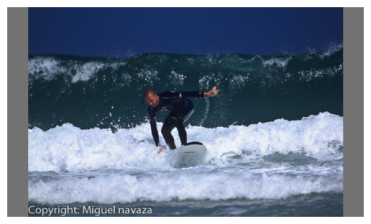

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# 假设 img 是你的图像，形状为 (3, 640, 1088)，dtype=float32，值在 [0,1]
# img = np.random.rand(3, 640, 1088).astype(np.float32)  # 模拟数据

# 转换为 HWC 格式
img_hwc = np.transpose(inputs[0].cpu().numpy().squeeze(), (1, 2, 0))  # 结果为 (640, 1088, 3)

# 直接显示
plt.imshow(img_hwc)
plt.axis('off')  # 可选：隐藏坐标轴
plt.show()
# plt.imshow(inputs[0].cpu().numpy().squeeze())

In [106]:
outputs, infer_time = engine(inputs)

torch.Size([10, 3, 640, 1088])


/tmp/ipykernel_3732203/2094542075.py:91: DeprecationWarning: Use get_tensor_mode instead.
  (inputs if engine.binding_is_input(i) else outputs).append(i)
/tmp/ipykernel_3732203/2094542075.py:100: DeprecationWarning: Use set_input_shape instead.
  context.set_binding_shape(inp_idx, (batch, 3, H, W))
/tmp/ipykernel_3732203/2094542075.py:108: DeprecationWarning: Use get_tensor_shape instead.
  shape = context.get_binding_shape(i)
/tmp/ipykernel_3732203/2094542075.py:110: DeprecationWarning: Use get_tensor_dtype instead.
  dtype = trt.nptype(engine.get_binding_dtype(i))
/tmp/ipykernel_3732203/2094542075.py:116: DeprecationWarning: Use get_tensor_mode instead.
  if engine.binding_is_input(i):
/tmp/ipykernel_3732203/2094542075.py:143: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  host_bufs[inp_idx][...] = inputs


In [114]:
outputs.shape

(10, 56, 14280)

In [107]:
infer_time

26.09436798095703

In [113]:
import torch
from torchvision.ops import nms  # or batched_nms if you have class ids

def batch_pose_postprocess(
    data: torch.Tensor,
    conf_thres: float = 0.25,
    iou_thres: float = 0.65
):
    """
    批量后处理 (Batch B, 56, N) -> 每张图各自的 (boxes, scores, kpts)
    """
    B, _, N = data.shape
    data = data.permute(0, 2, 1).contiguous()  # (B, N, 56)
    results = []
    for b in range(B):
        p = data[b]  # (N, 56)
        bboxes, scores, kpts = p[:, :4], p[:, 4], p[:, 5:].reshape(N, 17, 3)
        # 过滤置信度
        mask = scores > conf_thres
        if mask.sum() == 0:
            results.append((torch.zeros((0, 4)), torch.zeros((0,)), torch.zeros((0, 17, 3))))
            continue
        boxes, sc, kp = bboxes[mask], scores[mask], kpts[mask]
        # xywh -> xyxy
        xy, wh = boxes[:, :2], boxes[:, 2:]
        xyxy = torch.cat([xy - 0.5*wh, xy + 0.5*wh], dim=1)
        # NMS
        keep = nms(xyxy, sc, iou_thres)
        results.append((xyxy[keep], sc[keep], kp[keep]))
    return results

In [132]:
outputs = torch.tensor((outputs))

In [134]:
start = time.time()
results = batch_pose_postprocess(outputs)
end = time.time()
print(f'pose post process run time: {end-start}')

pose post process run time: 0.008383512496948242


In [135]:
# 10张需要9ms
## 测试模式
for _ in range(5): # 预热
    results = batch_pose_postprocess(outputs)
post_time = []
for _ in range(10):
    start = time.time()
    results = batch_pose_postprocess(outputs)
    end = time.time()
    post_time.append(end-start)
print(f'avg post run time:{sum(post_time)/len(post_time)}')

avg post run time:0.003733181953430176


In [136]:
len(results)

10

fp16->10张图片：infer:17ms, pose process: 3.7ms

In [137]:
result = results[0]

In [140]:
result[0].shape

torch.Size([1, 4])

In [141]:
len(result)

3

In [142]:
result[2].shape

torch.Size([1, 17, 3])

In [143]:
bboxes, scores, kpts = result[0], result[1], result[2]

In [151]:
dwdh = dwdh_list[0]
ratio = ratio_list[0]
draw = draw_list[0]

In [146]:
bboxes -= dwdh
bboxes /= ratio

In [147]:
bboxes[0]

tensor([234.4330, 164.0447, 388.0529, 296.9818])

In [149]:
from utils.config import COLORS, KPS_COLORS, LIMB_COLORS, SKELETON

In [156]:
str(images[0]).split('.')[0]

'/data/xl/Projects/EdgeLite/datasets/coco-pose/images/val2017/000000320696'

In [158]:
save_img_name = os.path.basename(str(images[0])).split('.')[0]+"_fp16trt_prediction.jpg"
save_img = os.path.join('assets', save_img_name)

In [159]:
for (bbox, score, kpt) in zip(bboxes, scores, kpts):
    bbox = bbox.round().int().tolist()
    color = COLORS['person']
    cv2.rectangle(draw, bbox[:2], bbox[2:], color, 2)
    cv2.putText(draw,
                f'person:{score:.3f}', (bbox[0], bbox[1] - 2),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.75, [225, 255, 255],
                thickness=2)
    for i in range(19):
        if i < 17:
            px, py, ps = kpt[i]
            if ps > 0.5:
                kcolor = KPS_COLORS[i]
                px = round(float(px - dw) / ratio)
                py = round(float(py - dh) / ratio)
                cv2.circle(draw, (px, py), 5, kcolor, -1)
        xi, yi = SKELETON[i]
        pos1_s = kpt[xi - 1][2]
        pos2_s = kpt[yi - 1][2]
        if pos1_s > 0.5 and pos2_s > 0.5:
            limb_color = LIMB_COLORS[i]
            pos1_x = round(float(kpt[xi - 1][0] - dw) / ratio)
            pos1_y = round(float(kpt[xi - 1][1] - dh) / ratio)

            pos2_x = round(float(kpt[yi - 1][0] - dw) / ratio)
            pos2_y = round(float(kpt[yi - 1][1] - dh) / ratio)

            cv2.line(draw, (pos1_x, pos1_y), (pos2_x, pos2_y),
                     limb_color, 2)
cv2.imwrite(str(save_img), draw)

True

# trt evaluation map50